In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets
import torchvision.transforms.v2 as v2
import torch.utils.data
import torch.optim as optim

In [22]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28,512),
            nn.ReLU(),
            nn.Linear(512,512),
            nn.ReLU(),
            nn.Linear(512,400)
        )

        self.decoder = nn.Sequential(
            nn.Linear(20,400),
            nn.ReLU(),
            nn.Linear(400,512),
            nn.ReLU(),
            nn.Linear(512,512),
            nn.ReLU(),
            nn.Linear(512,28*28),
            nn.Sigmoid()
        )

        self.mu = nn.Sequential(
            nn.Linear(400,20)
        )

        self.logvar = nn.Sequential(
            nn.Linear(400,20)
        )
    
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(mu)
        z = mu + eps * std
        return z
    
    def forward(self, x):
        x = x.view(-1,784)
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar
    
model = VAE().to("cpu")
print(model)

        

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=400, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=784, bias=True)
    (7): Sigmoid()
  )
  (mu): Sequential(
    (0): Linear(in_features=400, out_features=20, bias=True)
  )
  (logvar): Sequential(
    (0): Linear(in_features=400, out_features=20, bias=True)
  )
)


In [23]:
def loss_fn(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction="sum")
    KLD = - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (BCE + KLD) / x.size(0)

In [24]:
training_set = torchvision.datasets.MNIST(
    root="data",
    train = True,
    transform=v2.Compose([v2.ToImage(),v2.ToDtype(torch.float32, scale=True)])
)

In [25]:
batch_size = 64
Loaded_set = torch.utils.data.DataLoader(
    dataset=training_set,
    batch_size= batch_size,
    shuffle= True
)
optimizer = optim.Adam(model.parameters(),lr= 1e-3)

In [26]:
def train(model, dataloader, optimizer, loss_fn):
    model.train()
    training_loss = 0
    size = len(dataloader.dataset)
    for batch, (data,_) in enumerate(dataloader):
        optimizer.zero_grad()
        recon_x , mu, logvar = model(data)
        loss = loss_fn(recon_x, data, mu, logvar)
        loss.backward()
        optimizer.step()
        training_loss += loss.item()
    
        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(data)
            print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")

    



In [27]:
epoch = 5
for i in range(epoch):
    print(f"epoch = {i+1}")
    train(model,Loaded_set,optimizer,loss_fn)
    

epoch = 1
loss: 544.631531 [    0/60000]
loss: 193.059631 [ 6400/60000]
loss: 179.856323 [12800/60000]
loss: 168.919418 [19200/60000]
loss: 162.867081 [25600/60000]
loss: 154.695343 [32000/60000]
loss: 160.544815 [38400/60000]
loss: 158.801392 [44800/60000]
loss: 145.782745 [51200/60000]
loss: 139.400330 [57600/60000]
epoch = 2
loss: 136.067917 [    0/60000]
loss: 131.443237 [ 6400/60000]
loss: 136.757523 [12800/60000]
loss: 135.505875 [19200/60000]
loss: 134.974838 [25600/60000]
loss: 128.167587 [32000/60000]
loss: 124.098801 [38400/60000]
loss: 135.094955 [44800/60000]
loss: 129.587906 [51200/60000]
loss: 127.666763 [57600/60000]
epoch = 3
loss: 134.058350 [    0/60000]
loss: 124.680725 [ 6400/60000]
loss: 125.452194 [12800/60000]
loss: 125.789833 [19200/60000]
loss: 125.048859 [25600/60000]
loss: 133.152969 [32000/60000]
loss: 123.693832 [38400/60000]
loss: 121.802017 [44800/60000]
loss: 133.604248 [51200/60000]
loss: 125.997353 [57600/60000]
epoch = 4
loss: 124.676392 [    0/60000]

In [ ]:
torch.save(model.state_dict(),"models/model_VAE.pth")

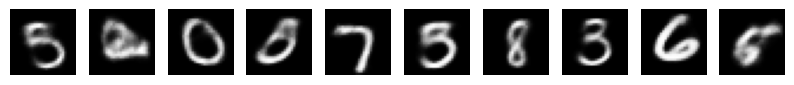

In [32]:
import matplotlib.pyplot as plt

model.eval()
n = 10
with torch.no_grad():
    z = torch.randn(n, 20)
    generated = model.decoder(z)
    generated  = generated.view(n, 28, 28)

fig, axes = plt.subplots(1, n, figsize=(n, 1.5))
for i in range(n):
    axes[i].imshow(generated[i], cmap="gray")
    axes[i].axis("off")
plt.show()

In [36]:
from ipywidgets import interact, FloatSlider

model.eval()
z1 = torch.randn(1, 20)
z2 = torch.randn(1, 20)

@interact(alpha=FloatSlider(min=0, max=1, step=0.01, value=0))
def show(alpha):
    with torch.no_grad():
        z = (1 - alpha) * z1 + alpha * z2
        img = model.decoder(z).view(28, 28).numpy()
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()



interactive(children=(FloatSlider(value=0.0, description='alpha', max=1.0, step=0.01), Output()), _dom_classes…